In [ ]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import os
from skimage.io import imread
from skimage.transform import resize
from PIL import Image


# Load your combined Visium data
adata = sc.read_h5ad("./TN_MIBC_4_samples/GSE171351_combined_visium.h5ad")

# Inspect the object
print(adata)
print(adata.obs.head())
print(adata.obsm.keys())


Image.MAX_IMAGE_PIXELS = None  # disable decompression bomb check

# Define folder where your images are located
img_folder = "./TN_MIBC_4_samples/"

# Map library IDs to image filenames
image_files = {
    "A1": "GSM5224027_A1.jpg",
    "B1": "GSM5224028_B1.jpg",
    "C1": "GSM5224029_C1.jpg",
    "D1": "GSM5224030_D1.jpg"
}

for lib_id, filename in image_files.items():
    img_path = os.path.join(img_folder, filename)
    if not os.path.exists(img_path):
        print(f"Warning: {img_path} not found!")
        continue

    # Load the image
    img = imread(img_path)
    orig_height, orig_width = img.shape[:2]


    # Attach resized image to AnnData
    if 'spatial' not in adata.uns:
        adata.uns['spatial'] = {}
    if lib_id not in adata.uns['spatial']:
        adata.uns['spatial'][lib_id] = {}

    adata.uns['spatial'][lib_id]['images'] = {'hires': img}


# Save updated AnnData
adata.write_h5ad("GSE171351_combined_visium_with_images.h5ad")
print("Images attached, coordinates rescaled, and AnnData saved.")

AnnData object with n_obs × n_vars = 4086 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'sampleID', 'Patient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'spatial'
                          in_tissue  array_row  array_col sampleID  \
AAACCGTTCGTCCAGG-1-0-0-0          1         52         42       A1   
AAACGAGACGGTTGAT-1-0-0-0          1         35         79       A1   
AAACTGCTGGCTCCAA-1-0-0-0          1         45         67       A1   
AAAGGCTACGGACCAT-1-0-0-0          1         62         54       A1   
AAAGGCTCTCGCGCCG-1-0-0-0          1 

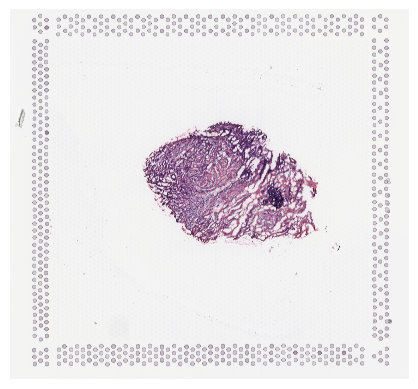

In [ ]:
##checking image attaching works
import matplotlib.pyplot as plt

plt.imshow(adata.uns['spatial']['A1']['images']['hires'])
plt.axis('off')
plt.show()


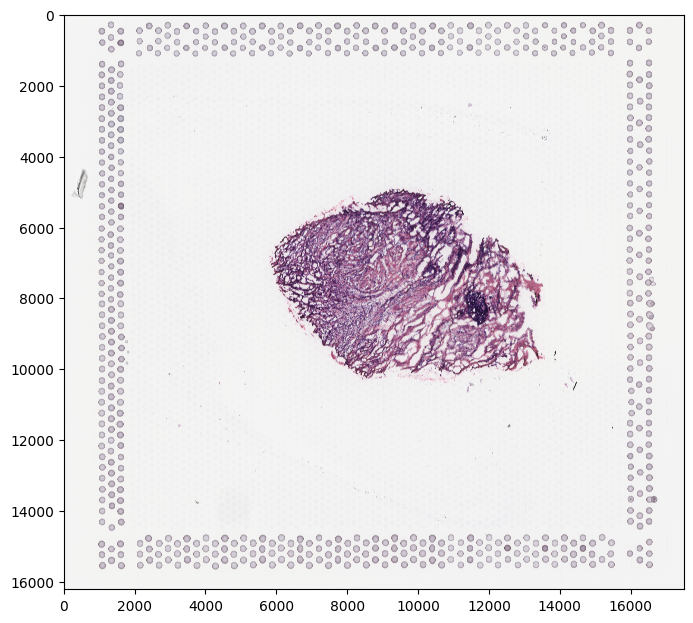

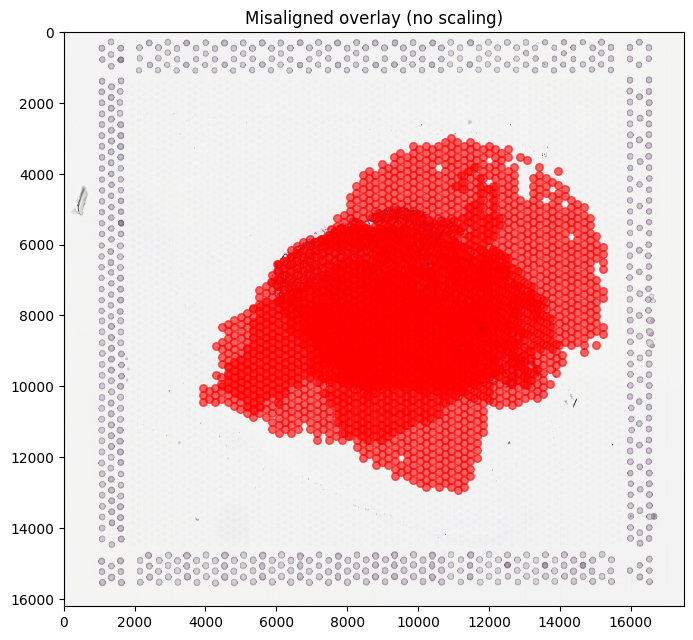

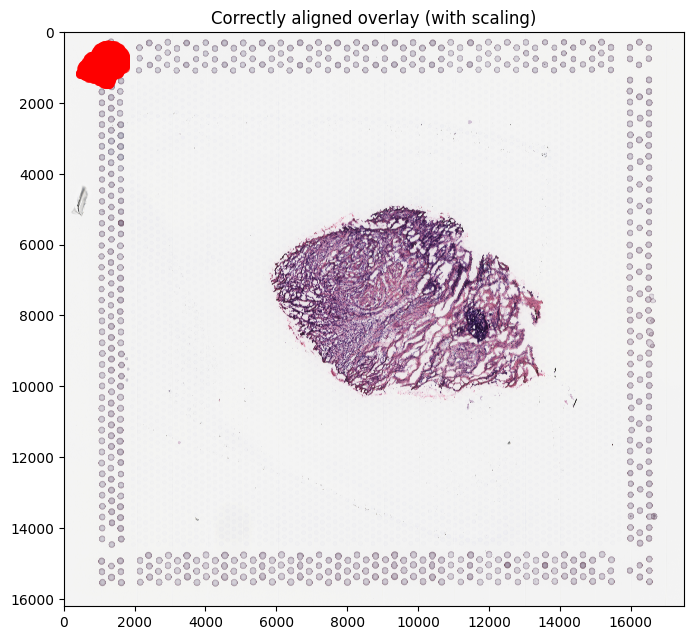

KeyError: 'Gad1'

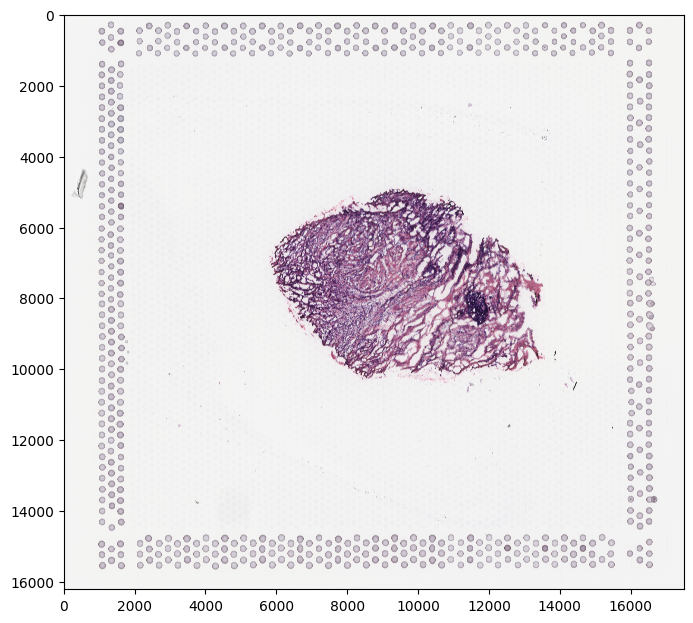

In [8]:
#Hutch tutorial -> https://rawcdn.githack.com/FredHutch/visium-toy/refs/heads/main/toy-visium.html
# Inspect available images and scalefactors
library_id = list(adata.uns['spatial'].keys())[0]
adata.uns['spatial'][library_id]['scalefactors']

# Extract image (hires)
img = adata.uns['spatial'][library_id]['images']['hires']

# Unscaled coordinates
coords_unscaled = adata.obsm['spatial']

# Display the histology image
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)

# Try plotting directly (we do not want this graph)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
ax.scatter(coords_unscaled[:, 0], coords_unscaled[:, 1],
           s=30, c='red', alpha=0.6)
ax.set_title("Misaligned overlay (no scaling)")
plt.show()

# Get scale factor for hires image
scale = adata.uns['spatial'][library_id]['scalefactors']['tissue_hires_scalef']

# Apply scaling
coords_scaled = adata.obsm['spatial'] * scale

# Correct overlay
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
ax.scatter(coords_scaled[:, 0], coords_scaled[:, 1],
           s=30, c='red', alpha=0.6)
ax.set_title("Correctly aligned overlay (with scaling)")
# ax.invert_yaxis()  # sometimes needed
plt.show()

# Overlay gene expression data
gene = "Gad1"
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
sc = ax.scatter(coords_scaled[:, 0], coords_scaled[:, 1],
                c=adata[:, gene].X.toarray().flatten(),
                cmap='magma', s=30)
ax.set_title(f"{gene} expression aligned to tissue")
# ax.invert_yaxis() 
plt.colorbar(sc, ax=ax)
plt.show()